<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/Gradient_Boosting_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient Boosting Classifier**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv',
    sep=',',
    engine='python',
    quoting=3,
    on_bad_lines='skip'
)

In [5]:
df = df.drop_duplicates().reset_index(drop=True)

df = df[['title','overview','genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [6]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [7]:
import nltk, re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess_text)

df['title'] = df['title'].str.lower()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['tags'])

df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce').fillna(0)

X = hstack((tfidf_matrix, df[['popularity']].values)).tocsr()

df['target'] = df['vote_average'].apply(lambda x: 1 if x >= 6 else 0)
y = df['target']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import *

X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X.toarray(), y, test_size=0.2, random_state=42, stratify=y
)

gb = GradientBoostingClassifier()
gb.fit(X_train_80, y_train_80)

y_pred_80 = gb.predict(X_test_20)
y_prob_80 = gb.predict_proba(X_test_20)[:,1]

print("=== GB (80-20) ===")
print("Accuracy:", accuracy_score(y_test_20, y_pred_80))
print("Precision:", precision_score(y_test_20, y_pred_80))
print("F1:", f1_score(y_test_20, y_pred_80))
print("ROC-AUC:", roc_auc_score(y_test_20, y_prob_80))

=== GB (80-20) ===
Accuracy: 0.8758620689655172
Precision: 0.5945945945945946
F1: 0.14012738853503184
ROC-AUC: 0.9004576354361232


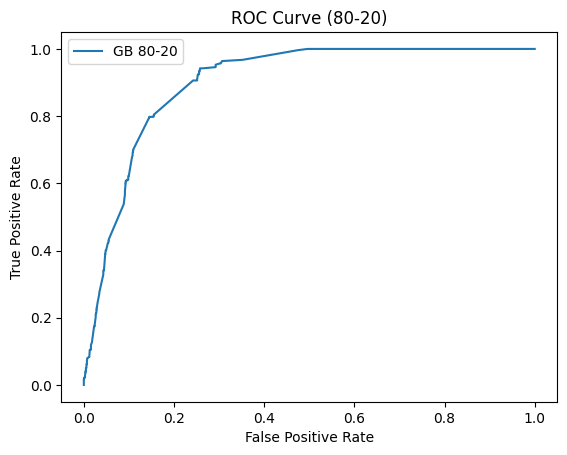

In [10]:
fpr_80, tpr_80, _ = roc_curve(y_test_20, y_prob_80)

plt.figure()
plt.plot(fpr_80, tpr_80, label="GB 80-20")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (80-20)")
plt.legend()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve
import numpy as np

X_dense = X.toarray()
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X_dense, y, test_size=0.3, random_state=42, stratify=y
)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train_70, y_train_70)

y_pred_70 = gb.predict(X_test_30)

probs = gb.predict_proba(X_test_30)
y_prob_70 = probs[:, 1] if probs.shape[1] == 2 else probs[:, 0]

print("=== Gradient Boosting (70-30) ===")
print("Accuracy :", accuracy_score(y_test_30, y_pred_70))
print("Precision:", precision_score(y_test_30, y_pred_70, zero_division=0))
print("F1 Score :", f1_score(y_test_30, y_pred_70, zero_division=0))

if len(np.unique(y_test_30)) > 1:
    roc_auc_70 = roc_auc_score(y_test_30, y_prob_70)
    print("ROC-AUC  :", roc_auc_70)
else:
    print("ROC-AUC  : Not possible")

=== Gradient Boosting (70-30 SAFE) ===
Accuracy : 0.8758430410790926
Precision: 0.5591397849462365
F1 Score : 0.2043222003929273
ROC-AUC  : 0.9027768392886102


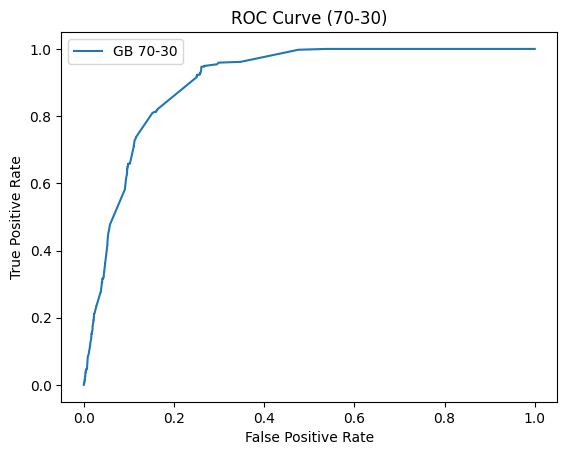

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

if len(np.unique(y_test_30)) > 1:
    fpr_70, tpr_70, _ = roc_curve(y_test_30, y_prob_70)

    plt.figure()
    plt.plot(fpr_70, tpr_70, label=f'GB (70-30) AUC={roc_auc_70:.2f}')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (70-30)")
    plt.legend()
    plt.show()
else:
    print("ROC Curve cannot be plotted")

In [13]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_model(movie_name, model, top_n=10):
    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "❌ Movie not found"

    idx = indices[movie_name]

    pred = model.predict_proba(X[idx].toarray())[0][1]

    sim_scores = cosine_similarity(X[idx], X).flatten()

    sim_indices = sim_scores.argsort()[-top_n-1:-1][::-1]
    recommended_movies = df['title'].iloc[sim_indices].values

    print(f"\nInput Movie: {movie_name}")
    print(f"Model Score: {pred:.2f}")

    if pred > 0.5:
        print("Recommended Movies:\n")
    else:
        print("Similar Movies (Low Rating Prediction):\n")

    for i, movie in enumerate(recommended_movies, 1):
        print(f"{i}. {movie}")

In [15]:
movie = input("Enter movie name: ").lower()
recommend_model(movie, gb)

Enter movie name: toy story

Input Movie: toy story
Model Score: 0.50
Similar Movies (Low Rating Prediction):

1. toy story 2
2. the snow queen 2: refreeze
3. tri bogatyrya na dalnikh beregakh
4. little longnose
5. slayers return
6. dragon ball z: super android 13
7. dragon ball z: broly - the legendary super saiyan
8. dragon ball: curse of the blood rubies
9. shrek the halls
10. lego dc comics super heroes: batman: be-leaguered
